In [1]:
from simulador_osmnx import simular_ciudad
import importlib
import simulador
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
importlib.reload(simulador)
import pandas as pd
import sklearn

In [2]:
print(simulador.CARPETA_DATA)
print(simulador.CARPETA_DATA.resolve())
print((simulador.CARPETA_DATA / "madrid").exists())
print((simulador.CARPETA_DATA / "madrid" / "puntos_b2c.csv").exists())

C:\Users\mario\Documents\fastapi_tutorial\GLIMS\data
C:\Users\mario\Documents\fastapi_tutorial\GLIMS\data
True
True


In [8]:
ciudad = "madrid"
barrio = "Moratalaz"

df_resultados = simular_ciudad(
    ciudad=ciudad,
    barrio_activo=barrio
)

df_resultados.round(2)

Red cargada correctamente
   Nodos: 31,455
   Aristas: 61,851

Asignando cada cliente al nodo más cercano de la red OSM...
Asociando clientes y centros a la red de OpenStreetMap...
3335 clientes asociados a nodos de la red.
Clientes asociados a la red: 3335
Centros logísticos asociados: 4

📍 Simulando MADRID - Moratalaz
Centroide: 40.40651211861125 -3.6449735865988853
Nodo: 40.4069535 -3.6443564
Separación: 0.0716913202856727
Centro logístico seleccionado: Amazon Logistics DMA3

Construyendo matriz de distancias sobre la red OSM (73 nodos)...
Calculando rutas mínimas con Dijkstra...
Matriz de distancias creada mediante Dijkstra.
Distancia por carretera CC → barrio: 5.47 km
OSM: 0.7439280445583871
HAV: 0.5214504806524561
✅ Moratalaz: 72 paquetes simulados


,ciudad,barrio,modelo,centro_logistico,paquetes,distancia_troncal_km,km_recorridos,numero_viajes,emisiones_co2_kg,costo_total_eur
0,madrid,Moratalaz,M1: Furgoneta Combustión desde CC,Amazon Logistics DMA3,72,5.47,37.80,2,8.31,47.93
1,madrid,Moratalaz,M2: Furgoneta Eléctrica desde CC,Amazon Logistics DMA3,72,5.47,37.80,2,0.00,41.57
2,madrid,Moratalaz,M3: CC -> Microhub -> Bicicleta,Amazon Logistics DMA3,72,5.47,29.23,5,2.41,69.12
3,madrid,Moratalaz,M4: CC -> PUDO -> Entrega a pie,Amazon Logistics DMA3,72,5.47,145.50,7,2.41,399.72
4,madrid,Moratalaz,M5: CC -> PUDO -> Recogida Cliente,Amazon Logistics DMA3,72,5.47,145.50,73,5.77,40.93


In [4]:
carpeta_ciudad = Path("../results") / ciudad
carpeta_ciudad.mkdir(
    parents=True,
    exist_ok=True
)

# Resumen completo

df_resultados.to_csv(
    carpeta_ciudad / f"resumen_{ciudad}.csv",
    index=False,
    encoding="utf-8-sig"
)


for barrio, df_barrio in df_resultados.groupby("barrio"):

    nombre_archivo = (
        barrio
        .replace(" ", "_")
        .replace("á", "a")
        .replace("é", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ú", "u")
    )

    df_barrio.to_csv(
        carpeta_ciudad / f"{nombre_archivo}.csv",
        index=False,
        encoding="utf-8-sig"
    )

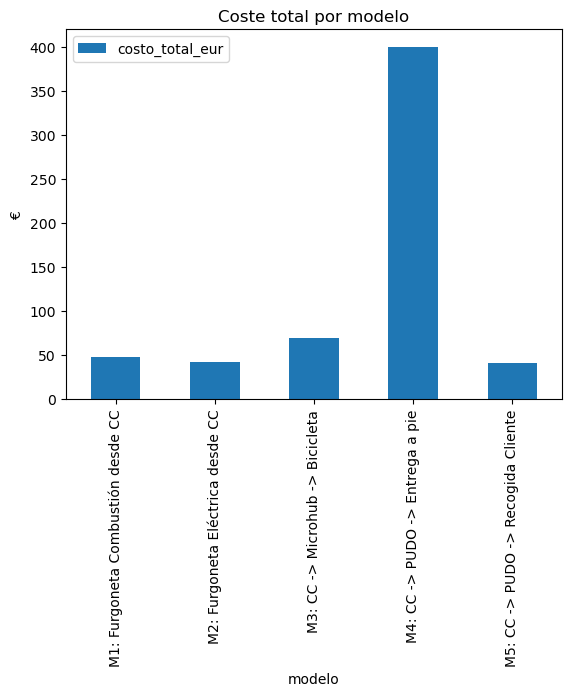

In [5]:
df_resultados.plot(
    x="modelo",
    y="costo_total_eur",
    kind="bar"
)
plt.title("Coste total por modelo")
plt.ylabel("€")
plt.show()

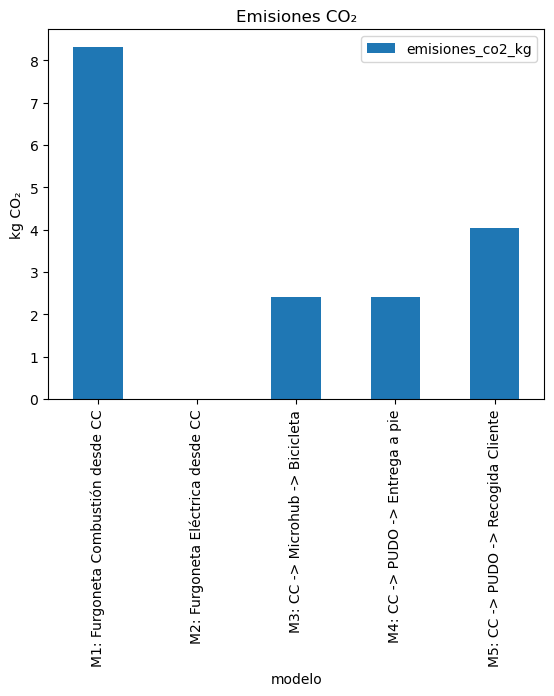

In [38]:
df_resultados.plot(
    x="modelo",
    y="emisiones_co2_kg",
    kind="bar"
)

plt.title("Emisiones CO₂")
plt.ylabel("kg CO₂")
plt.show()

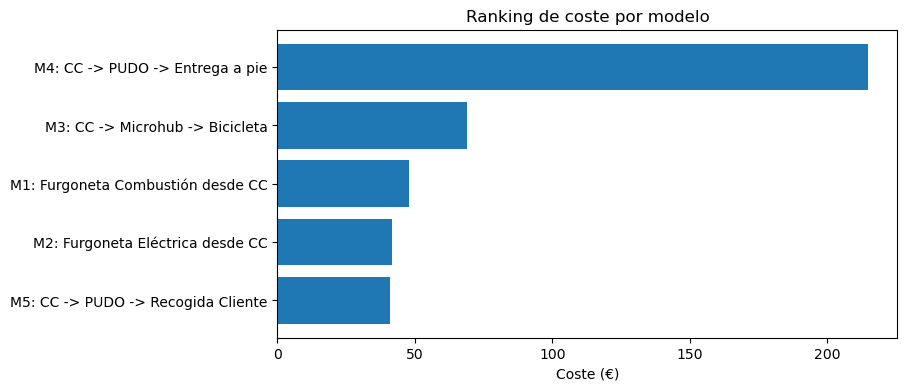

In [39]:
df_plot = (
    df_resultados[df_resultados["barrio"]=="Moratalaz"]
    .sort_values("costo_total_eur")
)

plt.figure(figsize=(8,4))

plt.barh(
    df_plot["modelo"],
    df_plot["costo_total_eur"]
)

plt.xlabel("Coste (€)")
plt.title("Ranking de coste por modelo")
plt.show()

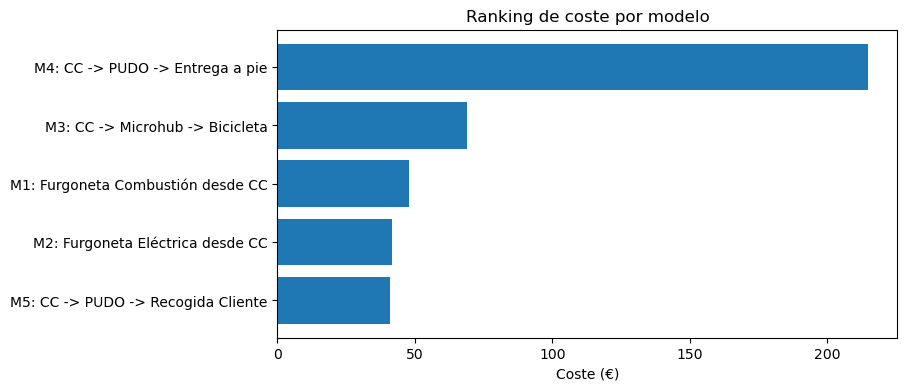

In [40]:
df_plot = (
    df_resultados[df_resultados["barrio"]=="Moratalaz"]
    .sort_values("costo_total_eur")
)

plt.figure(figsize=(8,4))

plt.barh(
    df_plot["modelo"],
    df_plot["costo_total_eur"]
)

plt.xlabel("Coste (€)")
plt.title("Ranking de coste por modelo")
plt.show()



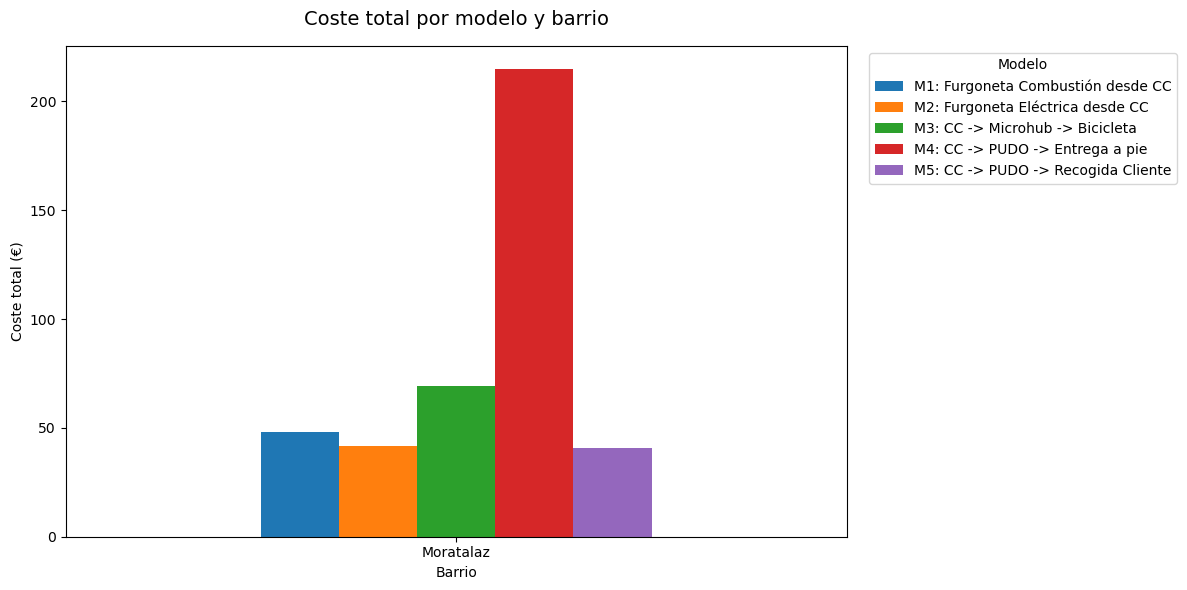

In [41]:
import matplotlib.pyplot as plt

pivot_coste = df_resultados.pivot_table(
    index="barrio",
    columns="modelo",
    values="costo_total_eur"
)


fig, ax = plt.subplots(figsize=(12, 6))

pivot_coste.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Coste total por modelo y barrio",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Barrio")
ax.set_ylabel("Coste total (€)")

ax.legend(
    title="Modelo",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

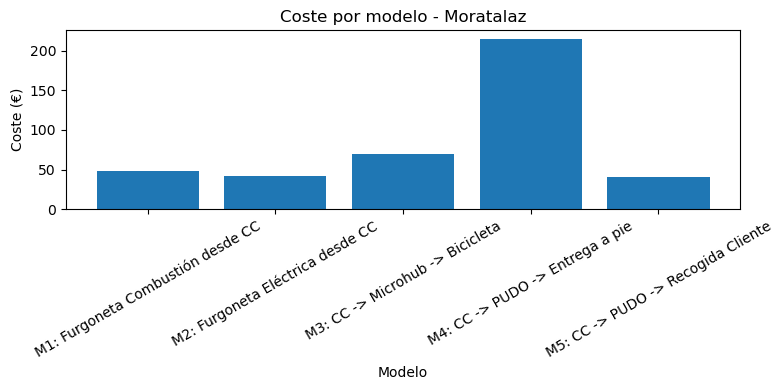

In [42]:
import matplotlib.pyplot as plt

for barrio in df_resultados["barrio"].unique():

    df_barrio = df_resultados[
        df_resultados["barrio"] == barrio
    ]

    plt.figure(figsize=(8, 4))

    plt.bar(
        df_barrio["modelo"],
        df_barrio["costo_total_eur"]
    )

    plt.title(f"Coste por modelo - {barrio}")
    plt.ylabel("Coste (€)")
    plt.xlabel("Modelo")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

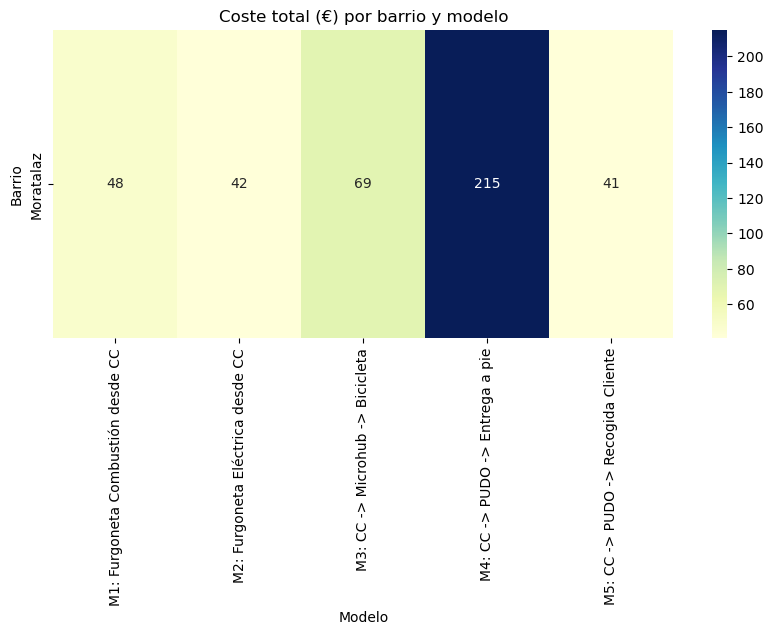

In [43]:
import seaborn as sns

tabla = df_resultados.pivot_table(
    index="barrio",
    columns="modelo",
    values="costo_total_eur"
)

plt.figure(figsize=(10, 4))

sns.heatmap(
    tabla,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Coste total (€) por barrio y modelo")
plt.xlabel("Modelo")
plt.ylabel("Barrio")

plt.show()

<Axes: xlabel='modelo', ylabel='barrio'>

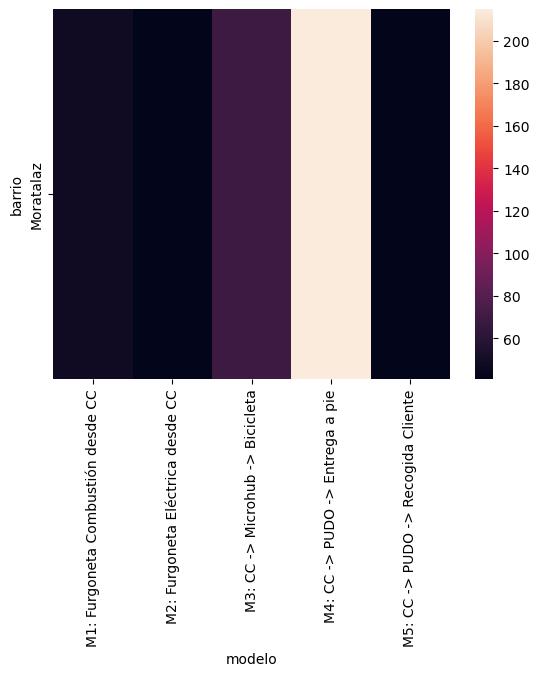

In [44]:
tabla = df_resultados.pivot_table(
    index="barrio",
    columns="modelo",
    values="costo_total_eur"
)

sns.heatmap(tabla)

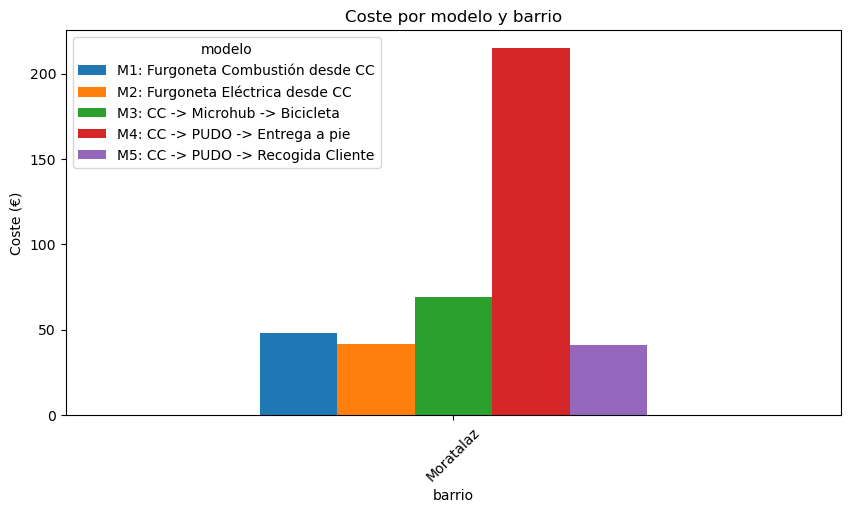

In [45]:
# 1. Coste por modelo y barrio
pivot_coste = df_resultados.pivot_table(
    index="barrio",
    columns="modelo",
    values="costo_total_eur"
)

pivot_coste.plot(kind="bar", figsize=(10, 5))
plt.title("Coste por modelo y barrio")
plt.ylabel("Coste (€)")
plt.xticks(rotation=45)
plt.show()

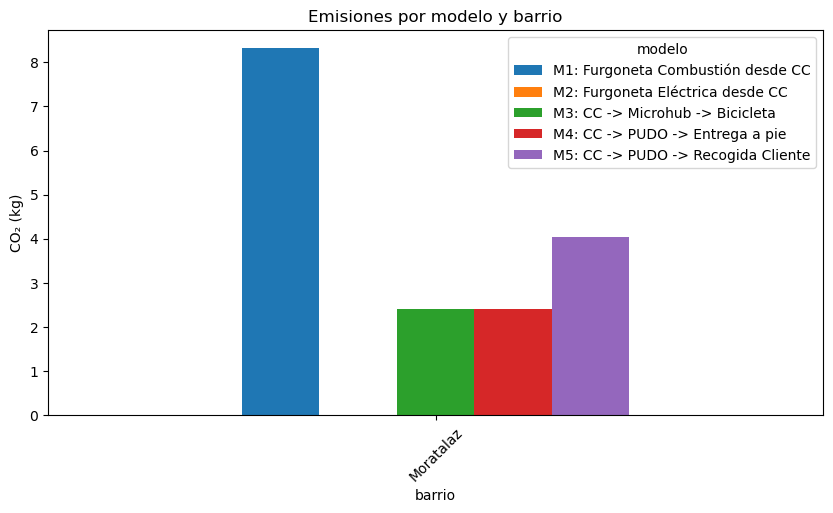

In [46]:
# 2. CO2 por modelo y barrio
pivot_co2 = df_resultados.pivot_table(
    index="barrio",
    columns="modelo",
    values="emisiones_co2_kg"
)

pivot_co2.plot(kind="bar", figsize=(10, 5))
plt.title("Emisiones por modelo y barrio")
plt.ylabel("CO₂ (kg)")
plt.xticks(rotation=45)
plt.show()

In [47]:
# 3. Tabla de ganadores
ganadores = df_resultados.loc[
    df_resultados.groupby("barrio")["costo_total_eur"].idxmin()
]

ganadores[
    ["barrio", "modelo", "costo_total_eur", "emisiones_co2_kg"]
].round(2)

,barrio,modelo,costo_total_eur,emisiones_co2_kg
4,Moratalaz,M5: CC -> PUDO -> Recogida Cliente,40.93,4.04


In [48]:
results_dir = Path("../results")

archivos = list(results_dir.glob("**/*.csv"))

df_total = pd.concat(
    [pd.read_csv(archivo) for archivo in archivos],
    ignore_index=True
)

df_total.head()

,ciudad,barrio,modelo,centro_logistico,paquetes,distancia_troncal_km,km_recorridos,numero_viajes,emisiones_co2_kg,costo_total_eur
0,madrid,Moratalaz,M1: Furgoneta Combustión desde CC,Amazon Logistics DMA3,72,5.47,37.80,2,8.31,47.93
1,madrid,Moratalaz,M2: Furgoneta Eléctrica desde CC,Amazon Logistics DMA3,72,5.47,37.80,2,0.00,41.57
2,madrid,Moratalaz,M3: CC -> Microhub -> Bicicleta,Amazon Logistics DMA3,72,5.47,29.23,5,2.41,69.12
3,madrid,Moratalaz,M4: CC -> PUDO -> Entrega a pie,Amazon Logistics DMA3,72,5.47,76.16,7,2.41,214.83
4,madrid,Moratalaz,M5: CC -> PUDO -> Recogida Cliente,Amazon Logistics DMA3,72,5.47,76.16,73,4.04,40.93


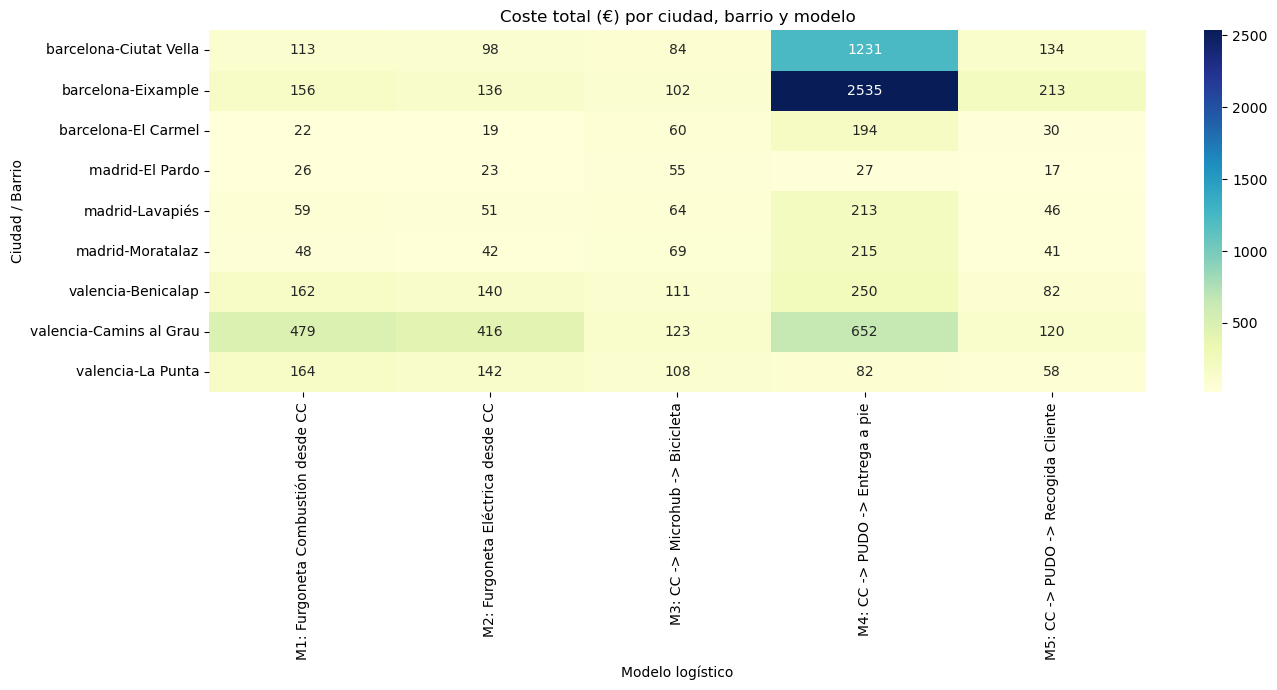

In [49]:
tabla_coste = df_total.pivot_table(
    index=["ciudad", "barrio"],
    columns="modelo",
    values="costo_total_eur",
    aggfunc="mean"
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    tabla_coste,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Coste total (€) por ciudad, barrio y modelo")
plt.xlabel("Modelo logístico")
plt.ylabel("Ciudad / Barrio")

plt.tight_layout()
plt.show()

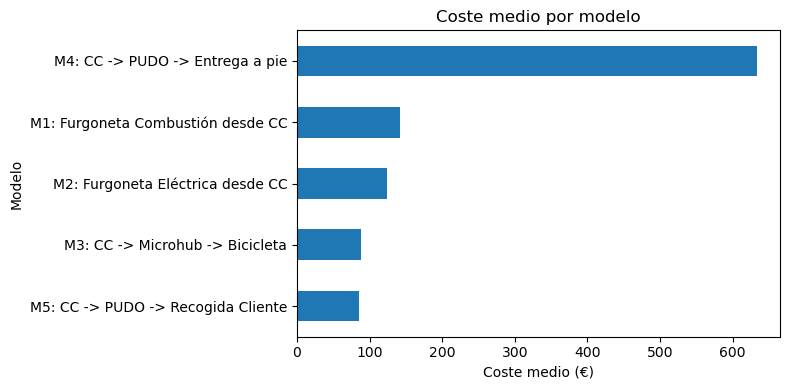

In [50]:
coste_medio = (
    df_total
    .groupby("modelo")["costo_total_eur"]
    .mean()
    .sort_values()
)

coste_medio.plot(
    kind="barh",
    figsize=(8, 4),
    title="Coste medio por modelo"
)

plt.xlabel("Coste medio (€)")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

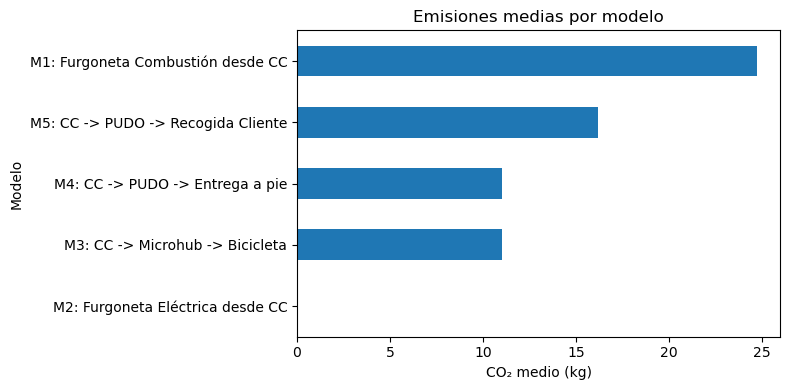

In [51]:
co2_medio = (
    df_total
    .groupby("modelo")["emisiones_co2_kg"]
    .mean()
    .sort_values()
)

co2_medio.plot(
    kind="barh",
    figsize=(8, 4),
    title="Emisiones medias por modelo"
)

plt.xlabel("CO₂ medio (kg)")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

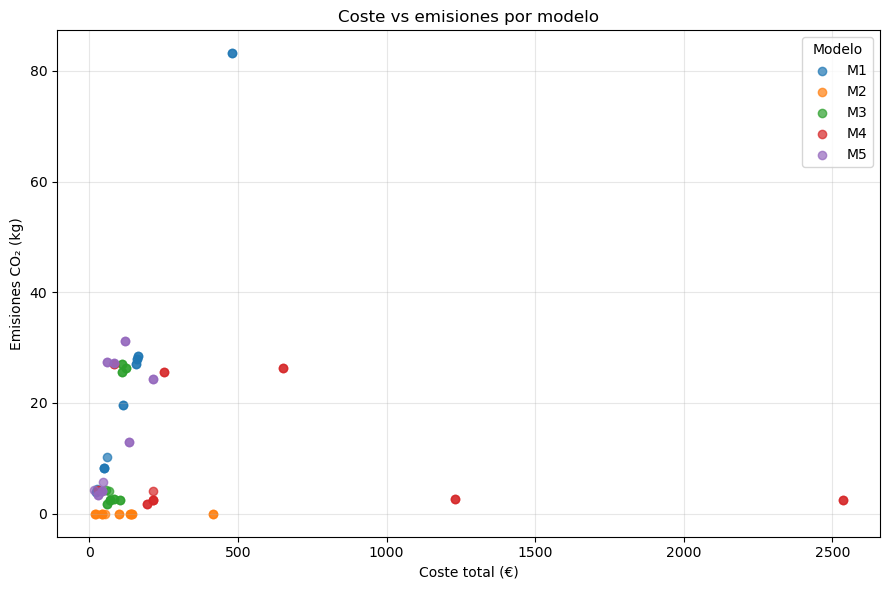

In [52]:
df_plot = df_total.copy()
df_plot["modelo_corto"] = df_plot["modelo"].str.extract(r"(M\d+)")

plt.figure(figsize=(9, 6))

for modelo in df_plot["modelo_corto"].unique():
    subset = df_plot[df_plot["modelo_corto"] == modelo]

    plt.scatter(
        subset["costo_total_eur"],
        subset["emisiones_co2_kg"],
        label=modelo,
        alpha=0.7
    )

plt.title("Coste vs emisiones por modelo")
plt.xlabel("Coste total (€)")
plt.ylabel("Emisiones CO₂ (kg)")
plt.legend(title="Modelo")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()